$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$

# 图 4.14

相较于极大极小拉丁超立方设计（MmLHD），最大投影设计的一大显著优势在于：最大投影准则支持序贯构造试验设计。我们先选取 $x_1 \in X$，再按照下述方式逐个添加 $x_2,\dots,x_n$：

$$
\boldsymbol{x}_{k+1}=\argmin_{\boldsymbol{x}\in \mathcal{X}}\sum_{i=1}^k\frac{1}{\prod_{j=1}^p(x_j-x_{ij})^2},\quad k=1,\dots,n-1
\tag{4.27}
$$

MaxPro 软件包中的 R 语言函数 MaxProAugment 可实现该构造方法。此种贪婪优化算法生成的设计，效果不及模拟退火算法与梯度优化算法构造的设计，但该方法灵活性强，能够解决多种不同类型的问题。

作为式 (4.27) 中序贯最大投影（MaxPro）构造方法的一项应用，我们考虑生成验证集以检验拟合模型拟合优度的问题。举例说明，选取仿真实验虚拟文库中的二维布兰宁函数：

$$
f(x)=\left(x_2-\frac{5.1}{4\pi^2}x_1^2+\frac{5}{\pi}x_1-6\right)^2+10\left(1-\frac{1}{8\pi}\right)\cos x_1+10,\quad x_1\in[-5,10],\;x_2\in[0,15] \tag{4.28}
$$

将该函数定义域缩放至 $[0,1]^2$ 后对应的函数图像如图 4.14 左图所示，图中蓝色圆点代表包含 10 个样本点的最大投影设计。接下来借助式 (4.27) 额外生成 10 个样本点用作验证集，在同一张图中以红色三角形表示。本文利用 R 语言程序包 rkriging 拟合普通克里金预测模型，并在验证集上计算均方根预测误差（RMSE）。作为对照，针对 100 组随机生成的 10 点验证集分别计算均方根预测误差，对应结果绘制为箱线图，见图 4.14 右图。不难发现，基于序贯最大投影方法构造的验证集所得均方根预测误差，高于箱线图上须的数值。原因在于：随机生成的验证集往往会包含靠近设计点的样本，这类样本易于预测，最终得到的均方根预测误差偏小；而序贯最大投影生成的验证样本在所有子空间内均远离设计点，由此构成的验证集预测难度更高。

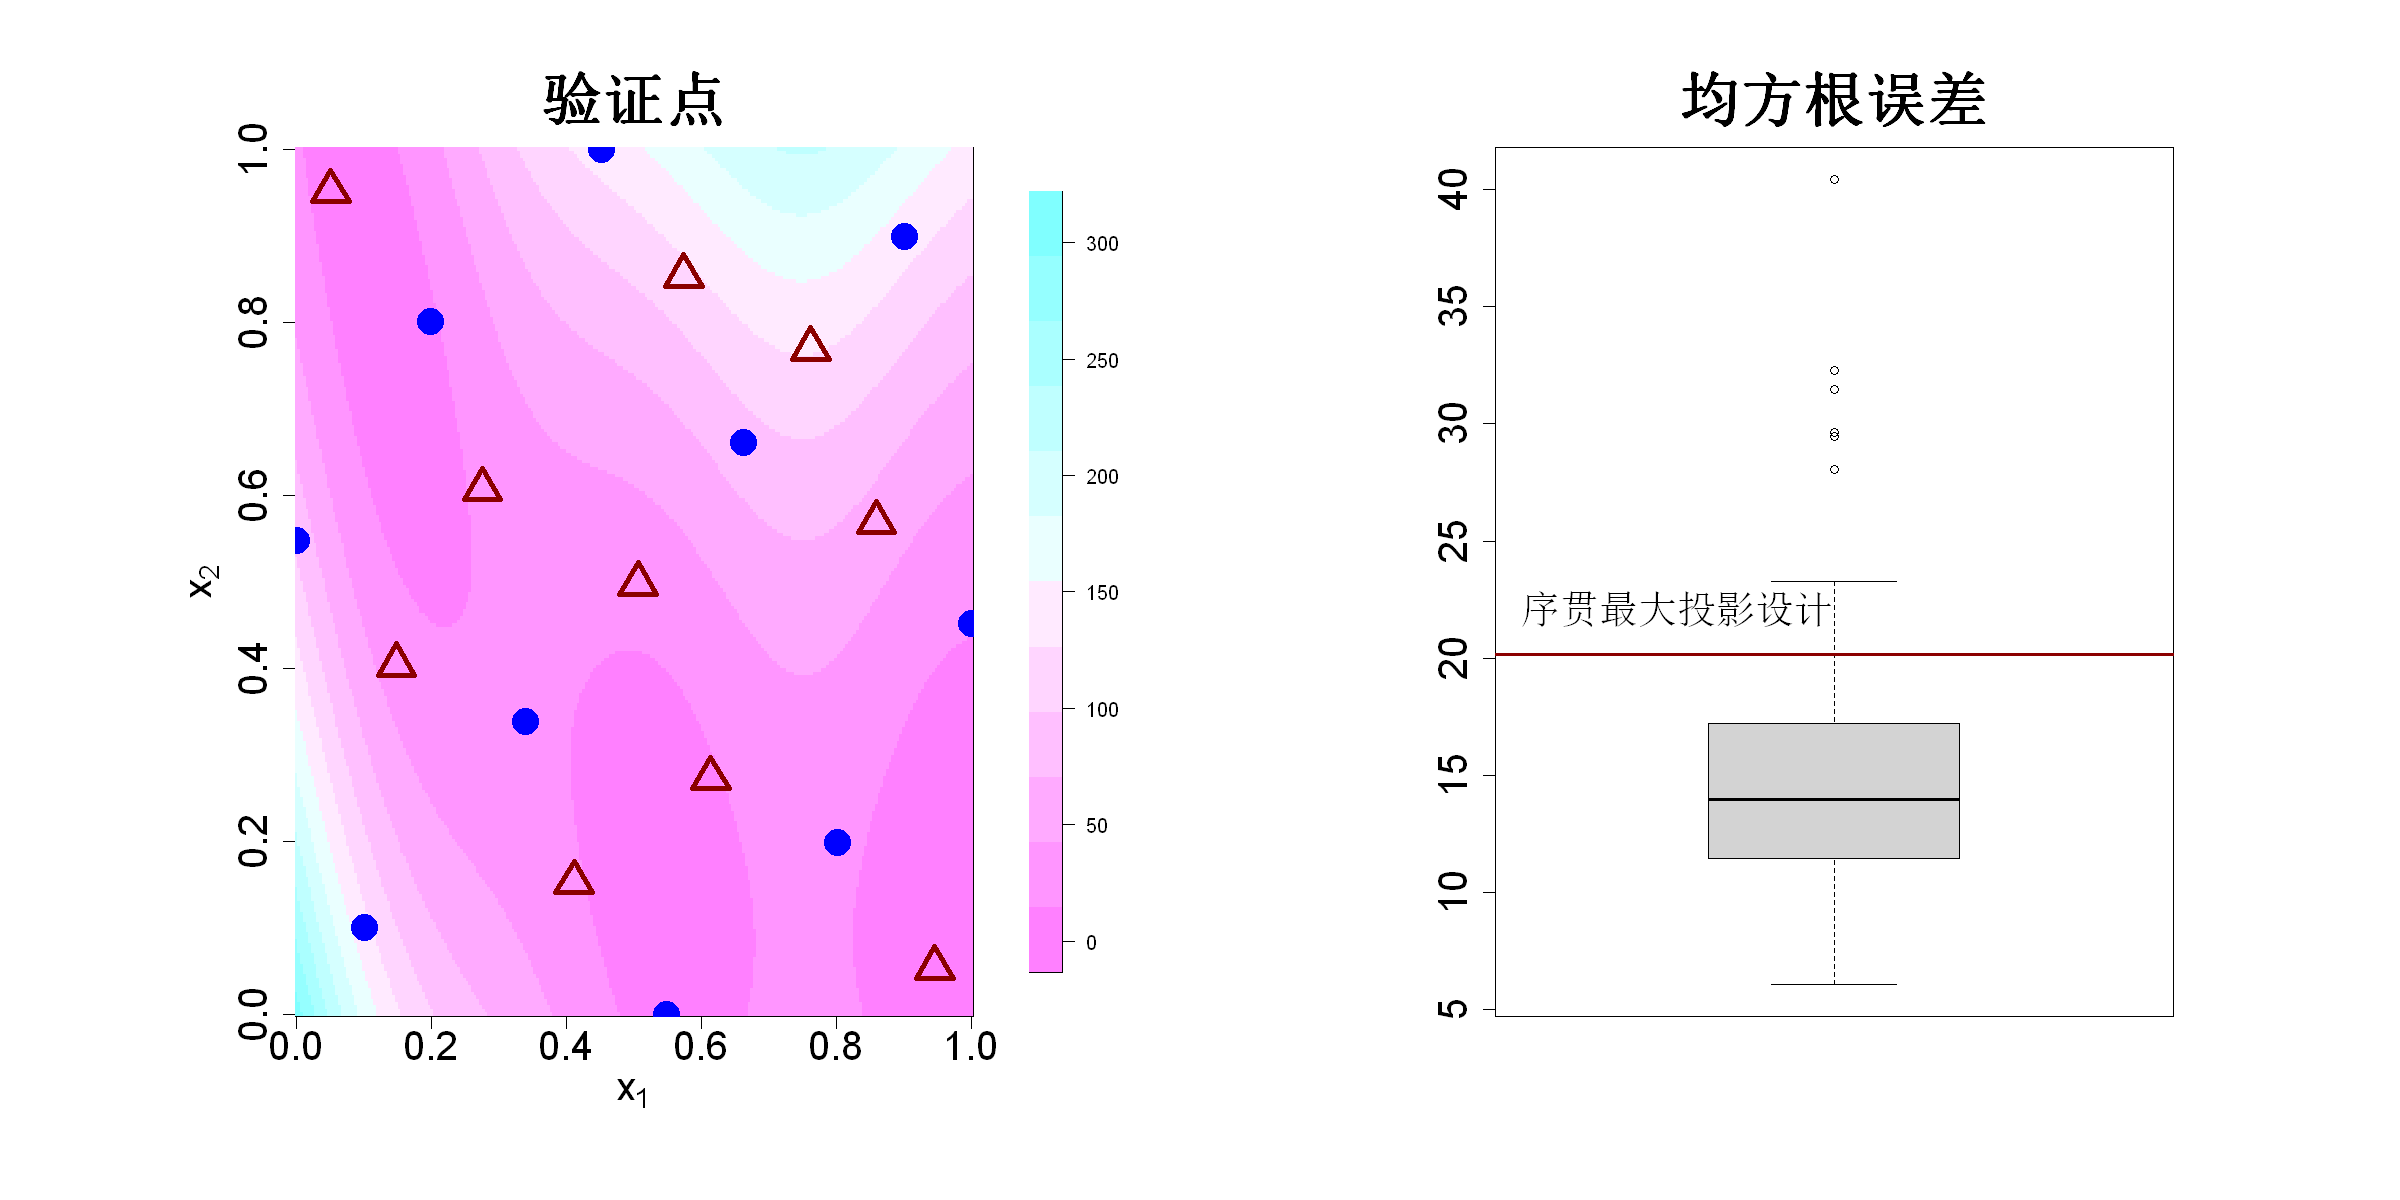

In [2]:
if(!dir.exists("data"))dir.create("data")
if(!file.exists("data/4.14-fc.csv")||!file.exists("data/4.14-rmse.csv")||!file.exists("data/4.14-para.csv")||!file.exists("data/4.14-D.csv")){
branin=function(x){
    x1=x[1]*15-5
    x2=x[2]*15
    (x2-5.1/(4*pi^2)*(x1^2)+5/pi*x1-6)^2+10*(1-1/(8*pi))*cos(x1)+10
}
p=2;n=10
set.seed(1)
library(SFDesign)
D=maxpro.optim(maxproLHD(n,p)$design)$design # 10x2
y=apply(D,1,branin)
library(MaxPro)
A=MaxProAugment(ExistDesign=D,CandDesign=CandPoints(N=10000,2),nNew=10)$Design[(n+1):20,] # 10x2
true=apply(A,1,branin)
library(rkriging)
a=Fit.Kriging(D,y,kernel.parameters=list(type="Gaussian"))
pred=Predict.Kriging(a,A)$mean
rmse0=sqrt(mean((pred-true)^2)) # 1x1
N=250
p1=seq(0,1,length=N) # 250x1
p2=seq(0,1,length=N) # 250x1
fc=matrix(0,nrow=N,ncol=N)
for(i in 1:N)for(j in 1:N)fc[i,j]=branin(c(p1[i],p2[j])) # 250x250
rmse=rep(0,100)
for(i in 1:100){
    u=matrix(runif(p*10),nrow=10,ncol=p)
    pred=Predict.Kriging(a,u)$mean
    true=apply(u,1,branin)
    rmse[i]=sqrt(mean((pred-true)^2)) # 100x1
}
write.csv(data.frame(D=D,A=A),file="data/4.14-D.csv",row.names=FALSE)
write.csv(data.frame(p1=p1,p2=p2,fc=fc),"data/4.14-fc.csv",row.names=FALSE)
write.csv(data.frame(rmse=rmse),"data/4.14-rmse.csv",row.names=FALSE)
write.csv(data.frame(rmse0=rmse0),"data/4.14-para.csv",row.names=FALSE)
}

df_fc=read.csv("data/4.14-fc.csv")
p1=df_fc$p1;p2=df_fc$p2
fc=as.matrix(df_fc[,paste0("fc.",1:250)])
df_rmse=read.csv("data/4.14-rmse.csv")
rmse=df_rmse$rmse
df_D=read.csv("data/4.14-D.csv")
D=as.matrix(df_D[,paste0("D.",1:2)])
A=as.matrix(df_D[,paste0("A.",1:2)])
para=read.csv("data/4.14-para.csv")
rmse0=para$rmse0

options(repr.plot.width=20,repr.plot.height=10)
par(mfrow=c(1,2))
library(fields)
imagePlot(p1,p2,fc,xlab=expression(x[1]),ylab=expression(x[2]),col=cm.colors(12,rev=TRUE),main="验证点",cex.main=3,cex.lab=2,cex.axis=2)
points(D,pch=16,col="blue",cex=3)
points(A,pch=2,col="darkred",lwd=4,cex=3)
boxplot(rmse,main="均方根误差",cex.main=3,cex.axis=2)
abline(h=rmse0,col="darkred",lwd=3)
text(.75,rmse0+2,"序贯最大投影设计",cex=2)

$$
\bigstar\;\diamond\;\bigstar\quad\boxed{\sigma_{\omega}\sigma}\quad\bigstar\;\diamond\;\bigstar
$$